# Multi-Depot Vehicle Routing Problem (with clustering)
---
Description:

The Multi-Depot Vehicle Routing Problem (MDVRP) is an extension of the Vehicle Routing Problem where a fleet of vehicles is based at 
multiple depots and must serve a set of customers with known demands. The objective is to assign customers to depots and design routes
for vehicles (respecting capacity, time-window, and route-length constraints) that minimize total cost (e.g., distance or time), while 
ensuring all customer demands are satisfied and each route starts and ends at the same depot.

- Optimization (combinatorial)
- Single-objective
- Constraints (yes)
---

### Import python libraries and set up the project directory

In [7]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.abspath('../../')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# Multi Depot Vehicles Routing Problem.
from utils import (load_data, Cluster,
                   initialize_population, cluster_customers_to_depots,
                   evaluate_solution)

### Import the custom GA code

In [8]:
# Import main classes.
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import cost_function
from pygenalgo.engines.standard_ga import StandardGA

# Import Selection Operator(s).
from pygenalgo.operators.selection.tournament_selector import TournamentSelector

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.order_crossover import OrderCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.swap_mutator import SwapMutator

### Read the data and cluster the customers to the depots

In [9]:
# Select a datafile.
# p01_c50_d4_v4
# p02_c50_d4_v2
# p03_c31_d1_v5
filepath = "data/p01_c50_d4_v4.json"

# Load the data from the filepath.
CUSTOMERS, DEPOTS = load_data(filepath)

# Create and store the clusters.
depot_clusters = cluster_customers_to_depots(DEPOTS,
                                             CUSTOMERS,
                                             verbose=True)

Depot-ID: 51 has  13 customers
Depot-ID: 52 has  17 customers
Depot-ID: 53 has  11 customers
Depot-ID: 54 has   9 customers


### Setup the fitness function

In [10]:
# Define the fitness function.
@cost_function(minimize=True)
def func_MDVRP(individual: Chromosome, cluster: Cluster) -> tuple[float, bool]:
    """
    This function computes the total distance
    travelled from all the cars of each depot.
    """
    # Validate the solution.
    total_distance, total_penalty = evaluate_solution(individual, cluster)
    
    # Penalty coefficient.
    p_coeff = 5.0
    
    # Estimate the fitness value.
    f_value = total_distance + (p_coeff * total_penalty)
    
    # Return the total fitness.
    return f_value, False
# _end_def_

In [11]:
# Total distance and penalty values.
total_d, total_p = 0.0, 0

# Store the solutions for plotting.
optimal_solutions = []

# Process all clusters (serially).
for cluster_k in depot_clusters:
    # Extract the depot.
    depot_k = cluster_k.depot
    
    # Extract the customers.
    customers_k = cluster_k.customers
    
    # Create the initial population.
    population_k = initialize_population(customers_k,
                                         depot_k.vehicles,
                                         n_pop=100)
    # Create a StandardGA object.
    test_GA = StandardGA(initial_pop=population_k,
                         fit_func=lambda x: func_MDVRP(x, cluster_k),
                         select_op=TournamentSelector(),
                         crossx_op=OrderCrossover(0.8),
                         mutate_op=SwapMutator(0.2))

    # Optimize the model.
    test_GA(epochs=800, elitism=True, verbose=True)
    
    # Extract the optimal solution from the GA.
    optimal_k = test_GA.best_chromosome()

    # Display an empty line.
    print(" ")
    
    # Extract the validation values.
    dist_k, pnlt_k = evaluate_solution(optimal_k, cluster_k,
                                       verbose=True)
    # Add the output values.
    total_d += dist_k
    total_p += pnlt_k

    # Store the optimal_k solution.
    optimal_solutions.append(optimal_k)

07/22/2026 13:13:29 INFO: Initial Avg. Fitness = -323.2374
07/22/2026 13:13:29 INFO: Epoch:     1 -> Avg. Fitness = -307.1261, Spread = 63.2287
07/22/2026 13:13:30 INFO: Epoch:    81 -> Avg. Fitness = -202.2624, Spread = 31.7455
07/22/2026 13:13:31 INFO: Epoch:   161 -> Avg. Fitness = -200.9865, Spread = 49.2011
07/22/2026 13:13:32 INFO: Epoch:   241 -> Avg. Fitness = -200.6983, Spread = 55.5820
07/22/2026 13:13:33 INFO: Epoch:   321 -> Avg. Fitness = -187.6340, Spread = 32.0012
07/22/2026 13:13:34 INFO: Epoch:   401 -> Avg. Fitness = -184.8682, Spread = 43.7829
07/22/2026 13:13:35 INFO: Epoch:   481 -> Avg. Fitness = -177.2731, Spread = 26.6138
07/22/2026 13:13:36 INFO: Epoch:   561 -> Avg. Fitness = -184.5329, Spread = 46.8822
07/22/2026 13:13:37 INFO: Epoch:   641 -> Avg. Fitness = -174.1223, Spread = 28.9840
07/22/2026 13:13:38 INFO: Epoch:   721 -> Avg. Fitness = -199.3958, Spread = 59.5301
07/22/2026 13:13:39 INFO: Final   Avg. Fitness = -190.6565
07/22/2026 13:13:39 INFO: Initia

Elapsed time: 10.090 seconds.
 
Depot-ID 51: -> Route 0, Distance 48.11, Demand 48
Depot-ID 51: -> Route 1, Distance 47.00, Demand 78
Depot-ID 51: -> Route 3, Distance 66.55, Demand 79


07/22/2026 13:13:40 INFO: Epoch:    81 -> Avg. Fitness = -261.6322, Spread = 48.1853
07/22/2026 13:13:42 INFO: Epoch:   161 -> Avg. Fitness = -280.4271, Spread = 85.0115
07/22/2026 13:13:43 INFO: Epoch:   241 -> Avg. Fitness = -263.4533, Spread = 79.9813
07/22/2026 13:13:44 INFO: Epoch:   321 -> Avg. Fitness = -271.7029, Spread = 68.1463
07/22/2026 13:13:46 INFO: Epoch:   401 -> Avg. Fitness = -272.8808, Spread = 64.4772
07/22/2026 13:13:47 INFO: Epoch:   481 -> Avg. Fitness = -270.3701, Spread = 71.5865
07/22/2026 13:13:48 INFO: Epoch:   561 -> Avg. Fitness = -248.1220, Spread = 37.1943
07/22/2026 13:13:49 INFO: Epoch:   641 -> Avg. Fitness = -286.4643, Spread = 77.7555
07/22/2026 13:13:51 INFO: Epoch:   721 -> Avg. Fitness = -264.8919, Spread = 65.8537
07/22/2026 13:13:52 INFO: Final   Avg. Fitness = -271.5508
07/22/2026 13:13:52 INFO: Initial Avg. Fitness = -197.1227
07/22/2026 13:13:52 INFO: Epoch:     1 -> Avg. Fitness = -187.5767, Spread = 35.1249


Elapsed time: 12.908 seconds.
 
Depot-ID 52: -> Route 0, Distance 98.54, Demand 79
Depot-ID 52: -> Route 1, Distance 35.08, Demand 51
Depot-ID 52: -> Route 2, Distance 74.79, Demand 78
Depot-ID 52: -> Route 3, Distance 23.50, Demand 54


07/22/2026 13:13:53 INFO: Epoch:    81 -> Avg. Fitness = -138.2494, Spread = 13.8584
07/22/2026 13:13:54 INFO: Epoch:   161 -> Avg. Fitness = -137.7637, Spread = 14.3223
07/22/2026 13:13:55 INFO: Epoch:   241 -> Avg. Fitness = -135.5206, Spread = 11.1237
07/22/2026 13:13:56 INFO: Epoch:   321 -> Avg. Fitness = -134.7278, Spread = 14.6276
07/22/2026 13:13:56 INFO: Epoch:   401 -> Avg. Fitness = -135.4860, Spread = 13.7817
07/22/2026 13:13:57 INFO: Epoch:   481 -> Avg. Fitness = -133.2427, Spread = 10.1042
07/22/2026 13:13:58 INFO: Epoch:   561 -> Avg. Fitness = -140.0794, Spread = 22.0279
07/22/2026 13:13:59 INFO: Epoch:   641 -> Avg. Fitness = -139.1152, Spread = 21.7530
07/22/2026 13:14:00 INFO: Epoch:   721 -> Avg. Fitness = -137.2517, Spread = 18.7754
07/22/2026 13:14:01 INFO: Final   Avg. Fitness = -136.5327
07/22/2026 13:14:01 INFO: Initial Avg. Fitness = -189.3171
07/22/2026 13:14:01 INFO: Epoch:     1 -> Avg. Fitness = -183.2267, Spread = 27.4257


Elapsed time: 8.816 seconds.
 
Depot-ID 53: -> Route 1, Distance 26.10, Demand 36
Depot-ID 53: -> Route 2, Distance 71.86, Demand 78
Depot-ID 53: -> Route 3, Distance 30.99, Demand 63


07/22/2026 13:14:02 INFO: Epoch:    81 -> Avg. Fitness = -123.1807, Spread = 12.9623
07/22/2026 13:14:03 INFO: Epoch:   161 -> Avg. Fitness = -126.7291, Spread = 17.4703
07/22/2026 13:14:03 INFO: Epoch:   241 -> Avg. Fitness = -121.9772, Spread = 14.9616
07/22/2026 13:14:04 INFO: Epoch:   321 -> Avg. Fitness = -122.2446, Spread = 15.6729
07/22/2026 13:14:05 INFO: Epoch:   401 -> Avg. Fitness = -129.2847, Spread = 20.6719
07/22/2026 13:14:06 INFO: Epoch:   481 -> Avg. Fitness = -128.8923, Spread = 22.1063
07/22/2026 13:14:06 INFO: Epoch:   561 -> Avg. Fitness = -120.5009, Spread = 11.9702
07/22/2026 13:14:07 INFO: Epoch:   641 -> Avg. Fitness = -126.7624, Spread = 18.5652
07/22/2026 13:14:08 INFO: Epoch:   721 -> Avg. Fitness = -122.7755, Spread = 14.4179
07/22/2026 13:14:08 INFO: Final   Avg. Fitness = -124.2602


Elapsed time: 7.617 seconds.
 
Depot-ID 54: -> Route 0, Distance 70.17, Demand 61
Depot-ID 54: -> Route 1, Distance 45.10, Demand 72


### Display the final solution along with the plot of the vehicles routes

Depot[51] -> [44] -> [45] -> [15] -> [37] -> [17] -> [51] 
Depot[51] -> [25] -> [18] -> [4] -> [51] 
Depot[51] -> [42] -> [19] -> [40] -> [41] -> [13] -> [51] 
Depot[52] -> [14] -> [24] -> [26] -> [31] -> [8] -> [1] -> [52] 
Depot[52] -> [27] -> [32] -> [11] -> [46] -> [52] 
Depot[52] -> [48] -> [7] -> [43] -> [23] -> [6] -> [52] 
Depot[52] -> [47] -> [12] -> [52] 
Depot[53] -> [9] -> [50] -> [16] -> [53] 
Depot[53] -> [39] -> [33] -> [10] -> [5] -> [38] -> [53] 
Depot[53] -> [49] -> [30] -> [34] -> [53] 
Depot[54] -> [22] -> [28] -> [3] -> [36] -> [35] -> [54] 
Depot[54] -> [20] -> [2] -> [29] -> [21] -> [54] 


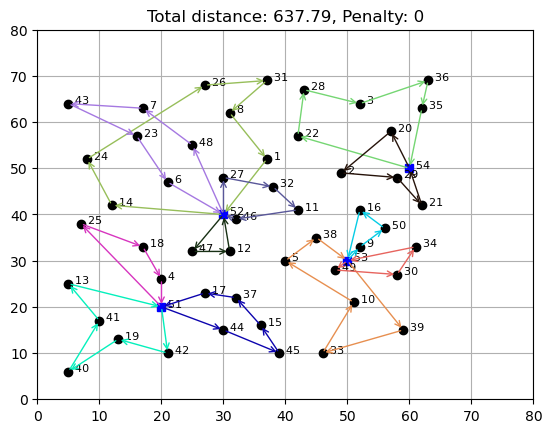

In [12]:
# Fix the rng for the colours.
fixed_rng = np.random.default_rng(756983756837456289375)

# Create a new figure.
fig = plt.figure()
ax = fig.add_subplot(111)

for optimal_k, cluster_k in zip(optimal_solutions,
                                depot_clusters):
    depot_k = cluster_k.depot

    n_vehicles = depot_k.vehicles
    
    customers_k = cluster_k.customers

    n_customers = len(customers_k)

    # Add the customers.
    for c in customers_k:
        ax.plot(c.x, c.y, 'ko')
        ax.annotate(f'  {c.ID}', xy=(c.x, c.y), fontsize=8)
    # _end_for_

    # Add the depot.
    ax.plot(depot_k.x, depot_k.y, 'bs')
    ax.annotate(f'  {depot_k.ID}',
                xy=(depot_k.x, depot_k.y), fontsize=8)

    # Reshape the solution array.
    final_k = np.reshape(optimal_k.values(),
                         (n_customers, n_vehicles))

    # Start computing the total cost.
    for i in range(n_vehicles):
        # Exclude the negative entries.
        customer_ids = final_k[final_k[:, i] >= 0, i]

        # If the array is emtpy
        # continue to the next.
        if customer_ids.size == 0:
            continue

        # Initialize the route using
        # the depot as starting point.
        route = [depot_k]

        # Start printing the route info.
        print(f"Depot[{depot_k.ID}]", end="")

        # Generate the route for this vehicle.
        for c_id in customer_ids.tolist():
            for customer_i in customers_k:
                if customer_i.ID == c_id:
                    route.append(customer_i)
        # _end_for_

        # Get the length of the route.
        n_stops = len(route)

        # Generate a random colour for the route.
        color_i = fixed_rng.random(3)
        
        # Iterate through the route.
        for j, start_point in enumerate(route):
            # Get the coordinates of the first point.
            xj, yj = start_point.x, start_point.y
    
            # The next index ('k') should point
            # at the beginning of the list once
            # we reach at the end.
            k = j + 1 if j < n_stops - 1 else 0
    
            # Get the coordinates of the both points.
            xk, yk = route[k].x, route[k].y
    
            # Put an arrow to show direction.
            ax.annotate("", xy=(xj, yj), xytext=(xk, yk),
                        arrowprops=dict(arrowstyle="<-",
                                        color=color_i))
            # Print the next stop.
            print(f" -> [{route[k].ID}]", end="")
        # _end_for_

        # Print a new line to declutter the screen.
        print(" ")
# _end_for_

ax.grid()
ax.set_xlim([0, 80])
ax.set_ylim([0, 80])

plt.title(f"Total distance: {total_d:.2f}, Penalty: {total_p}")

# Save the figure.
plt.savefig("MDVRP_cluster.pdf", format="pdf", dpi=300)

### End-Of-File